In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
# Настройка стиля
sns.set(style="whitegrid")

# 1. ЗАГРУЗКА И ОБЪЕДИНЕНИЕ ДАННЫХ
# Загружаем исходные файлы
drivers = pd.read_csv('drivers.csv')
passengers = pd.read_csv('passengers.csv')
taxi_2 = pd.read_csv('taxi_2.csv')

# Объединяем данные: сначала merge для водителей и пассажиров, затем склейка с taxi_2
df_taxi = pd.concat([drivers.merge(passengers, on='journey_id'), taxi_2]).reset_index(drop=True)

In [ ]:
# Проверка пропущенных значений
most_empty_column = df_taxi.isna().sum().idxmax()
print(f"Колонка с максимумом пропусков: {most_empty_column}")


Колонка с максимумом пропусков: driver_score


Доля заказов по платформам (%):
source
iPhone     42.37
web        33.20
Android    21.35
iPad        2.48
Wap         0.59
Name: proportion, dtype: float64


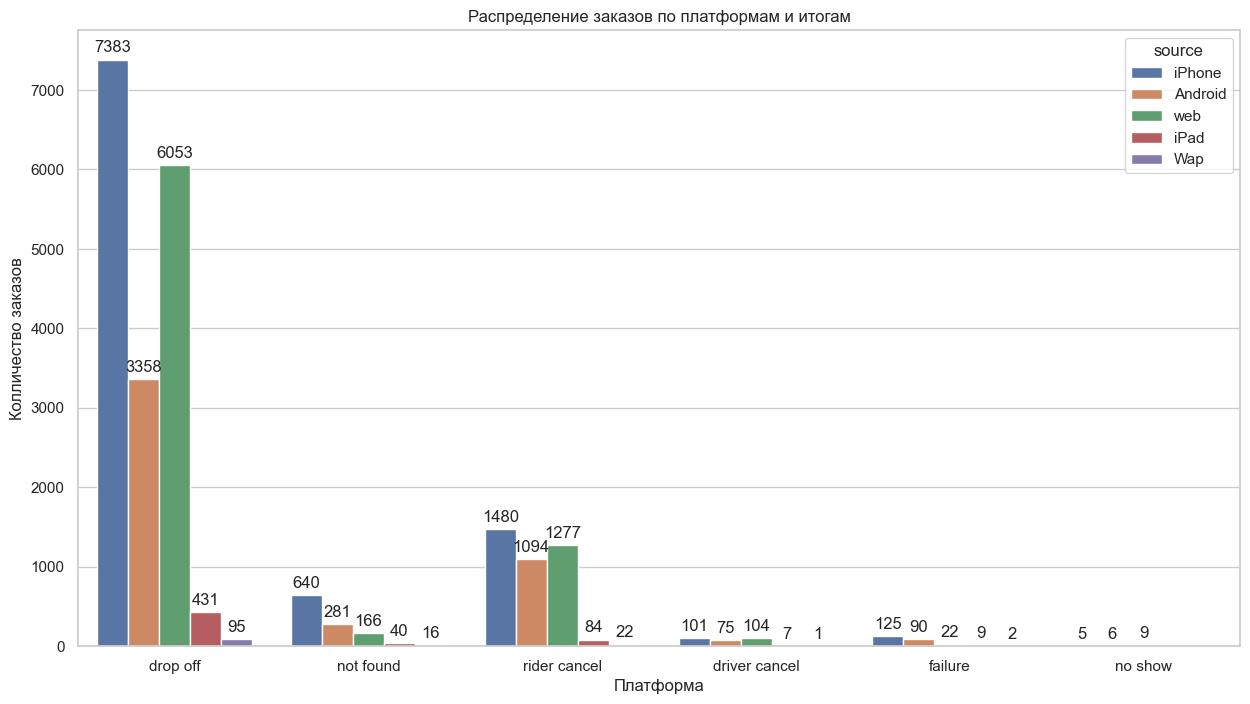

In [5]:
# 2. АНАЛИЗ ПЛАТФОРМ (SOURCE)
source_distribution = round(df_taxi.source.value_counts(normalize=True) * 100, 2)
print("Доля заказов по платформам (%):")
print(source_distribution)

# Визуализация итогового состояния заказов по платформам
plt.figure(figsize=(15, 8))
ax = sns.countplot(data=df_taxi, x='end_state', hue='source')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Распределение заказов по платформам и итогам')
plt.xlabel('Платформа')
plt.ylabel('Колличество заказов')
plt.show()



In [ ]:
#Больше всего заказов со статусом drop off совершено с платформы iPhone
#На Android количество отмененных поездок (rider cancel) меньше, чем на iPhone
#Наибольшая разница между количеством drop off и rider cancel наблюдается для платформы iPhone


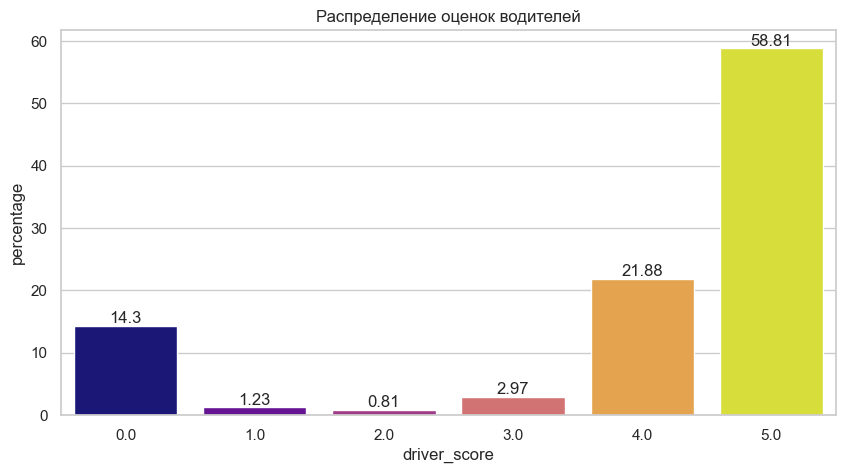

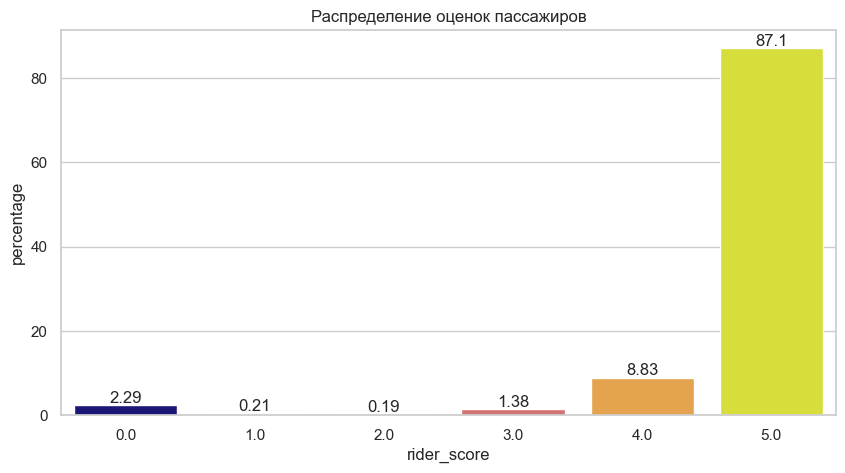

In [ ]:
# 3. АНАЛИЗ ОЦЕНОК (DRIVER & RIDER SCORES)
def plot_score_bar(df, column, title):
    score_data = round(df[column].value_counts(normalize=True) * 100, 2) \
                .reset_index() \
                .rename(columns={'proportion': 'percentage'}) \
                .sort_values(column)
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=score_data, x=column, y='percentage', hue=column, palette='plasma', legend=False)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(title)
    plt.show()

plot_score_bar(df_taxi, 'driver_score', 'Распределение оценок водителей')
plot_score_bar(df_taxi, 'rider_score', 'Распределение оценок пассажиров')


In [ ]:
#Более чем в 80% случаев водители поставили клиентам 5 звездочек
#Водители ставят меньше оценок 0, чем клиенты

In [ ]:
# 4. РАБОТА СО ВРЕМЕНЕМ И ОПОЗДАНИЯМИ
# Приведение к формату datetime
time_cols = ['start_at', 'end_at', 'arrived_at']
df_taxi[time_cols] = df_taxi[time_cols].apply(pd.to_datetime)

# Расчет времени ожидания (wait_time) в минутах
df_taxi['wait_time'] = (df_taxi['arrived_at'] - df_taxi['start_at']).dt.total_seconds() / 60
median_wait = df_taxi['wait_time'].median()
print(f"Медианное время подачи: {int(median_wait)} мин.")

# Анализ опозданий для типа 'reserved'
df_taxi['wait_time'] = df_taxi['wait_time'].fillna(0)
reserved_delays = df_taxi.query('start_type == "reserved" and wait_time > 0') \
                        .groupby('driver_id').size() \
                        .reset_index(name='delay_count') \
                        .sort_values('delay_count', ascending=False)

# РАСЧЕТ LATE_SCORE (Доля опозданий более 5 минут от общего числа поездок водителя)
driver_journeys = df_taxi.groupby('driver_id').agg(total_trips=('journey_id', 'nunique'))
driver_delays = df_taxi.query('start_type == "reserved" and wait_time > 5') \
                       .groupby('driver_id').agg(delay_trips=('journey_id', 'nunique'))

driver_efficiency = driver_journeys.merge(driver_delays, on='driver_id', how='left').fillna(0)
driver_efficiency['late_score'] = round(100 * driver_efficiency.delay_trips / driver_efficiency.total_trips)
print("Статистика опозданий (late_score):")
print(driver_efficiency['late_score'].describe())

Медианное время подачи: 5 мин.
Статистика опозданий (late_score):
count    168.000000
mean       3.494048
std        6.849972
min        0.000000
25%        0.000000
50%        1.000000
75%        4.000000
max       50.000000
Name: late_score, dtype: float64


In [ ]:
#На колличество опозданий ВЛИЯЛО Число взятых заказов
#НЕ ВЛИЯЛО Непунктуальность водителя (доля опозданий от всех его поездок у этого водителя больше, 
#чем соответствующие доли у остальных опаздывающих водителей)

/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_67315/1259910958.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_taxi, x='month', palette='plasma', order=month_order)


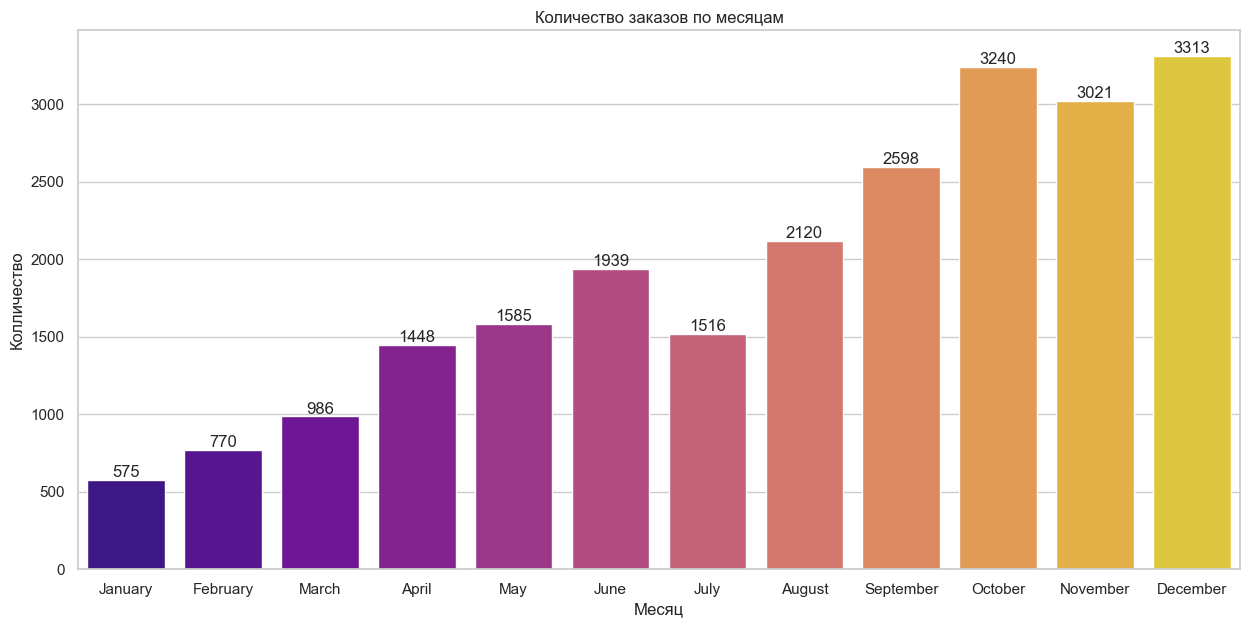

/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_67315/1259910958.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mau, x='month', y='user_id', palette='plasma', order=month_order)


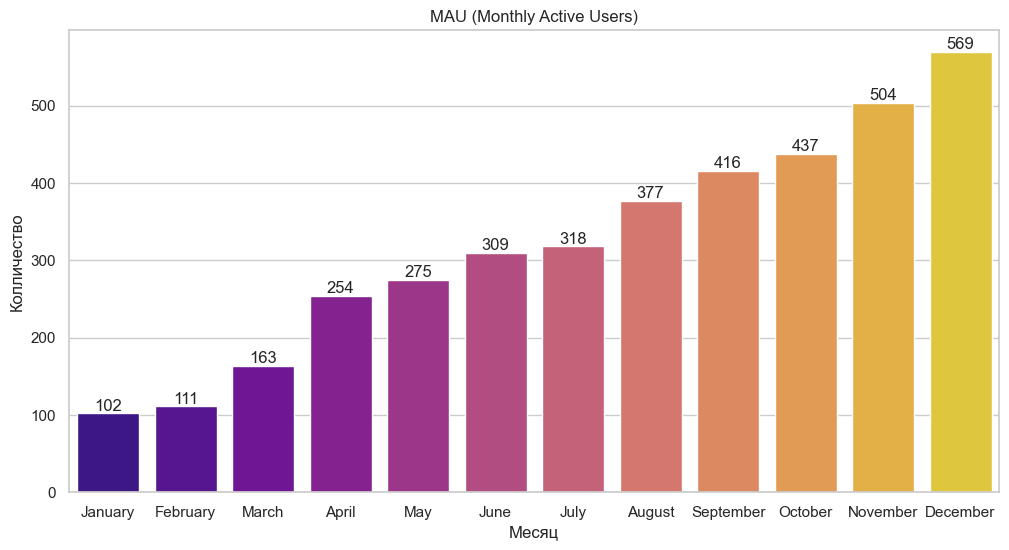

In [ ]:
# 5. СЕЗОННОСТЬ И АКТИВНОСТЬ (MAU)
df_taxi['month'] = df_taxi['start_at'].dt.month_name()
df_taxi['weekday'] = df_taxi['start_at'].dt.day_name()

# Заказы по месяцам
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(15, 7))
ax = sns.countplot(data=df_taxi, x='month', palette='plasma', order=month_order)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Колличество')
plt.show()

# Расчет MAU (уникальные пользователи в месяц)
mau = df_taxi.groupby('month', as_index=False).user_id.nunique()
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=mau, x='month', y='user_id', palette='plasma', order=month_order)
for container in ax.containers:
    ax.bar_label(container)
plt.title('MAU (Monthly Active Users)')
plt.xlabel('Месяц')
plt.ylabel('Колличество')
plt.show()



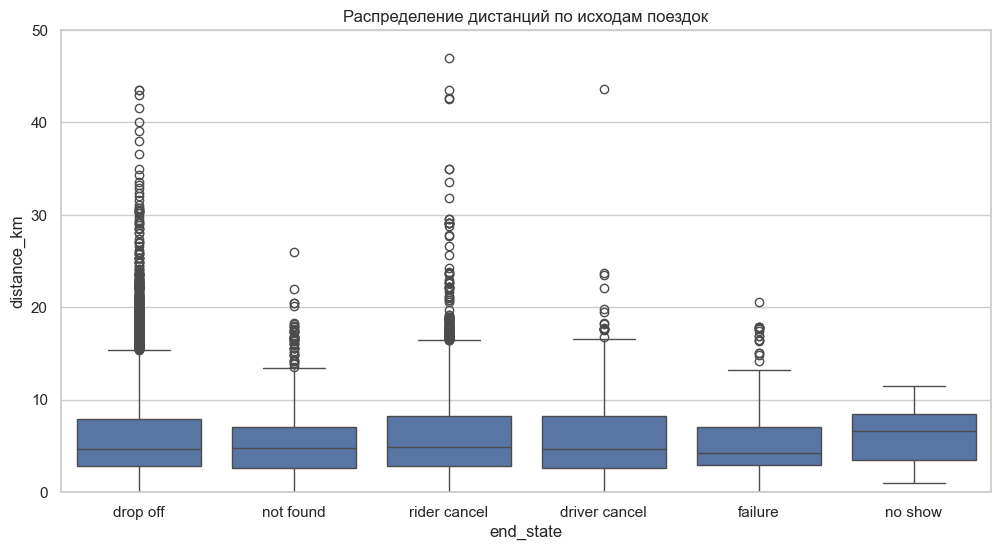

In [ ]:
# 6. ГЕОДАННЫЕ И ДИСТАНЦИЯ (HAVERSINE)
# ПРЕДВАРИТЕЛЬНАЯ ОЧИСТКА: ЗАМЕНЯЕМ ЗАПЯТЫЕ НА ТОЧКИ И ПРИВОДИМ К FLOAT
geo_cols = ['start_lat', 'start_lon', 'end_lat', 'end_lon']
df_taxi[geo_cols] = df_taxi[geo_cols].replace(',', '.', regex=True).astype(float)

def haversine_vectorized(start_lat, end_lat, start_lon, end_lon):
    start_lat, start_lon, end_lat, end_lon = map(np.radians, [start_lat, start_lon, end_lat, end_lon])
    dlat = end_lat - start_lat 
    dlon = end_lon - start_lon
    # ИСПРАВЛЕННАЯ ФОРМУЛА: dlon/2 ВНУТРИ СИНУСА
    a = np.sin(dlat/2)**2 + np.cos(start_lat) * np.cos(end_lat) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return 6371 * c

df_taxi['distance_km'] = haversine_vectorized(df_taxi["start_lat"], df_taxi["end_lat"], 
                                             df_taxi["start_lon"], df_taxi["end_lon"])
# Визуализация дистанций через Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_taxi, x='end_state', y='distance_km')
plt.ylim(0, 50) # ЗУМИРУЕМ, ЧТОБЫ ОТСЕЧЬ ВЫБРОСЫ GPS
plt.title('Распределение дистанций по исходам поездок')
plt.show()


/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_63721/722863108.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cancel_rate, x='hour_start', y='rate', palette='magma')


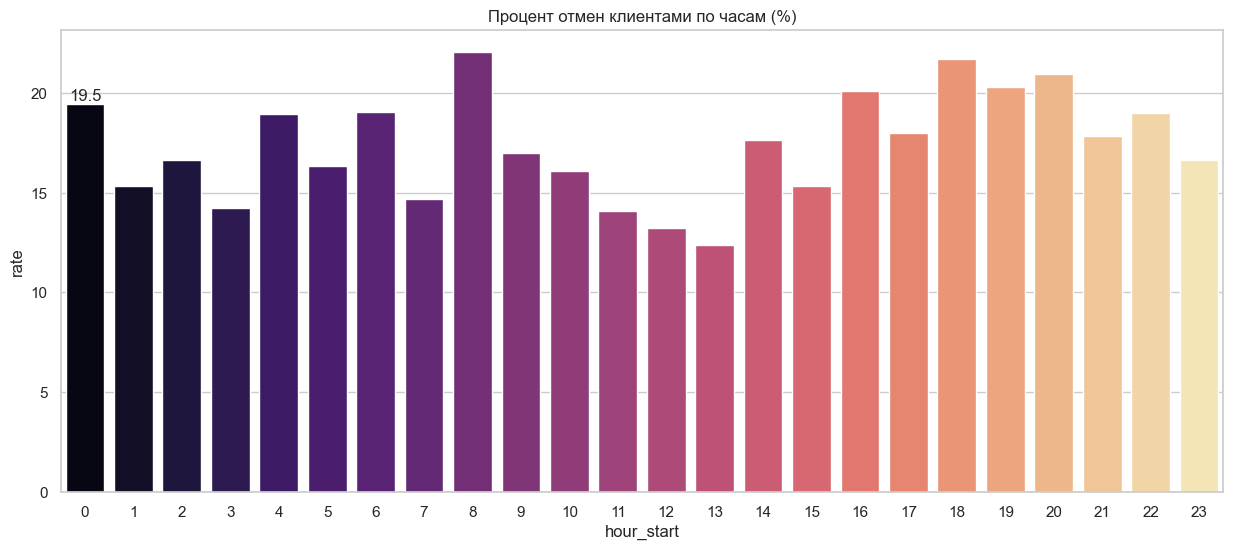

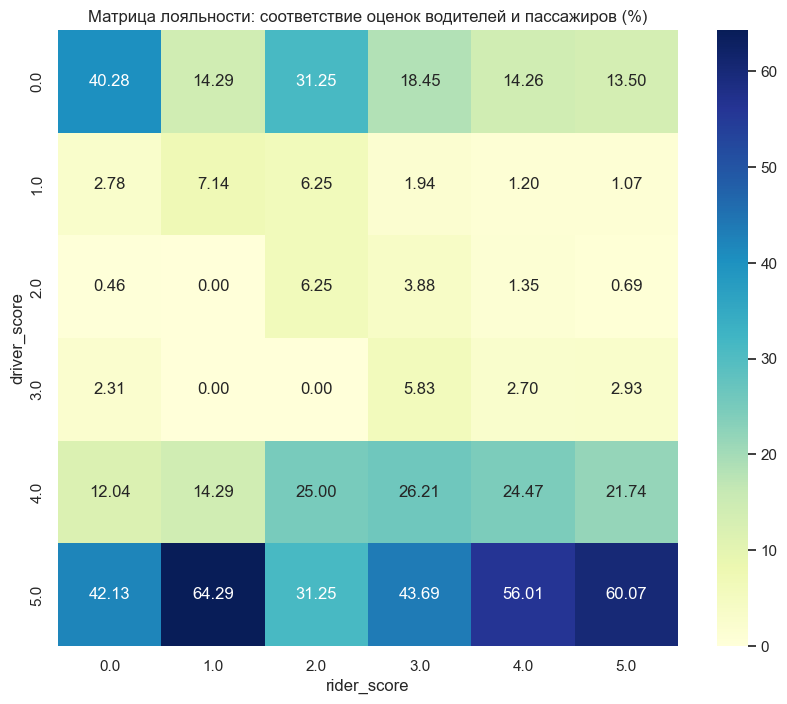

In [ ]:
# 7. АНАЛИЗ ОТМЕН ПО ЧАСАМ
df_taxi['hour_start'] = df_taxi['start_at'].dt.hour

# Доля отмен (Cancel Rate) по часам
cancel_rate = (df_taxi.query('end_state == "rider cancel"').groupby('hour_start').size() / 
               df_taxi.groupby('hour_start').size() * 100).reset_index(name='rate')

# 8. МАТРИЦА ЛОЯЛЬНОСТИ (HEATMAP)
# Удаляем пустые оценки и строим кросс-таблицу
df_scores_cleaned = df_taxi.dropna(subset=['driver_score', 'rider_score']).copy()
loyalty_matrix = round(pd.crosstab(df_scores_cleaned['driver_score'], 
                                  df_scores_cleaned['rider_score'], 
                                  normalize='columns') * 100, 2)

plt.figure(figsize=(10, 8))
sns.heatmap(loyalty_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Матрица лояльности: соответствие оценок водителей и пассажиров (%)')
plt.show()